## __MLB Payroll vs Wins__ ##

### ___Objective___ ###
The goal of this notebook is to:
- Load Lahman Datasets Salaries and Wins
- Perform Exploratory Data Analysis
- Answer these questions:
    1. Do richer teams win more?
    2. Are there low-payroll successful teams?
    3. Which teams overspend?
    4. Which teams are efficient?



In [5]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
salaries = pd.read_csv('../data/salaries.csv')
teams = pd.read_csv('../data/teams.csv')

# Inspect Data
print(salaries.head())
print(teams.head())

print(salaries.info())
print(teams.info())


   yearID teamID lgID   playerID   salary
0    2004    SFN   NL  aardsda01   300000
1    2007    CHA   AL  aardsda01   387500
2    2008    BOS   AL  aardsda01   403250
3    2009    SEA   AL  aardsda01   419000
4    2010    SEA   AL  aardsda01  2750000
   yearID lgID teamID franchID divID  Rank   G  Ghome   W   L  ...    DP  \
0    1871  NaN    BS1      BNA   NaN     3  31    NaN  20  10  ...  24.0   
1    1871  NaN    CH1      CNA   NaN     2  28    NaN  19   9  ...  16.0   
2    1871  NaN    CL1      CFC   NaN     8  29    NaN  10  19  ...  15.0   
3    1871  NaN    FW1      KEK   NaN     7  19    NaN   7  12  ...   8.0   
4    1871  NaN    NY2      NNA   NaN     5  33    NaN  16  17  ...  14.0   

      FP                     name                          park  attendance  \
0  0.834     Boston Red Stockings           South End Grounds I         NaN   
1  0.829  Chicago White Stockings       Union Base-Ball Grounds         NaN   
2  0.818   Cleveland Forest Citys  National Associatio

In [6]:
# Aggregate payroll by team and year
team_payroll = salaries.groupby(['yearID', 'teamID'])['salary'].sum().reset_index()
team_payroll.rename(columns={'salary': 'payroll'}, inplace=True)

# Keep only relevant columns from teams
teams_small = teams[['yearID', 'teamID', 'W', 'L', 'WSWin']]

# Merge payroll with team performance
df = pd.merge(team_payroll, teams_small, on=['yearID', 'teamID'])
print(df.head())

   yearID teamID   payroll   W   L WSWin
0    1985    ATL  14807000  66  96     N
1    1985    BAL  11560712  83  78     N
2    1985    BOS  10897560  81  81     N
3    1985    CAL  14427894  90  72     N
4    1985    CHA   9846178  85  77     N


In [7]:
# Create metrics
df['win_percentage'] = df['W'] / (df['W'] + df['L'])
df['cost_per_win'] = df['payroll'] / df['W']

In [8]:
# Analyze correlation
print(df[['payroll', 'W']].describe())
print(df[['payroll', 'W']].corr())

            payroll           W
count  9.180000e+02  918.000000
mean   6.004325e+07   79.943355
std    4.330958e+07   11.840224
min    8.800000e+05   43.000000
25%    2.543571e+07   71.250000
50%    5.053732e+07   80.000000
75%    8.441608e+07   89.000000
max    2.319789e+08  116.000000
          payroll         W
payroll  1.000000  0.254328
W        0.254328  1.000000


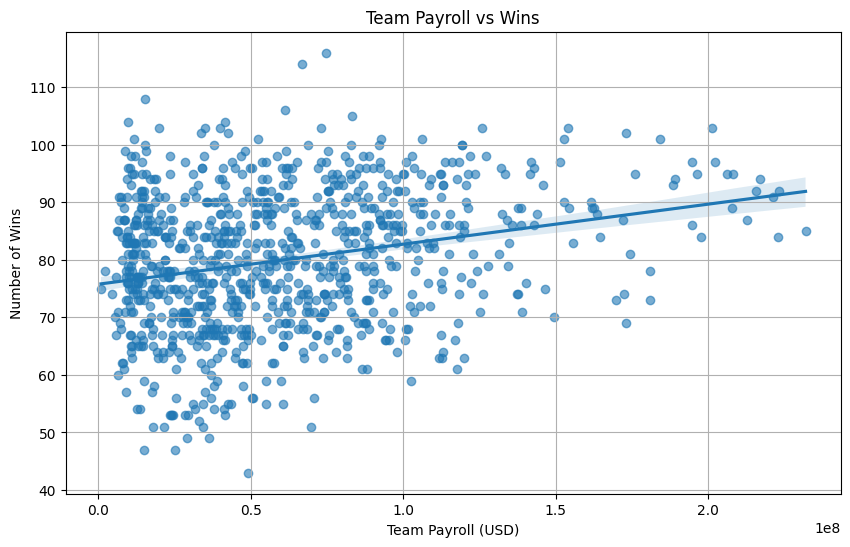

In [9]:
# Create visualizations: Scatter plot of payroll vs wins
plt.figure(figsize=(10, 6))

sns.regplot(
        data = df,
        x = 'payroll',
        y = 'W',
        scatter_kws={'alpha': 0.6}
)
plt.title('Team Payroll vs Wins')
plt.xlabel('Team Payroll (USD)')
plt.ylabel('Number of Wins')
plt.grid(True)
plt.show()

In [10]:
# Best value teams (lowest cost per win)
best_value = df.sort_values('cost_per_win').head(10)
print(best_value[['yearID', 'teamID', 'payroll', 'W', 'cost_per_win']])

     yearID teamID  payroll   W  cost_per_win
76     1987    TEX   880000  75  11733.333333
73     1987    SEA  2263500  78  29019.230769
21     1985    SEA  4613000  74  62337.837838
97     1988    PIT  5998500  85  70570.588235
12     1985    MIN  5764821  77  74867.805195
64     1987    MIN  6397500  85  75264.705882
66     1987    MON  6942052  91  76286.285714
102    1988    TEX  5342131  70  76316.157143
50     1986    TEX  6743119  87  77507.114943
65     1987    ML4  7293224  91  80145.318681


In [11]:
# Highest payroll teams
highest_payroll = df.sort_values('payroll', ascending=False).head(10)
print(highest_payroll[['yearID', 'teamID', 'payroll', 'W']])

     yearID teamID    payroll   W
815    2013    NYA  231978886  85
811    2013    LAN  223362196  92
905    2016    NYA  222997792  84
901    2016    LAN  221288380  91
841    2014    LAN  217014600  94
871    2015    LAN  215792000  92
875    2015    NYA  212751957  87
575    2005    NYA  208306817  95
665    2008    NYA  207896789  89
725    2010    NYA  206333389  95


In [12]:
# Save results to CSV 
df.to_csv('../data/team_payroll_wins.csv', index=False)

# Summary and Way Ahead
print("Analysis complete. Results saved to '../data/team_payroll_wins.csv'.")
print("Next steps: Build advanced visuals and regression models")

Analysis complete. Results saved to '../data/team_payroll_wins.csv'.
Next steps: Build advanced visuals and regression models


In [13]:
# Correlation Strength
correlation = df['payroll'].corr(df['W'])
print("Correlation between payroll and wins:", round(correlation, 3))

Correlation between payroll and wins: 0.254


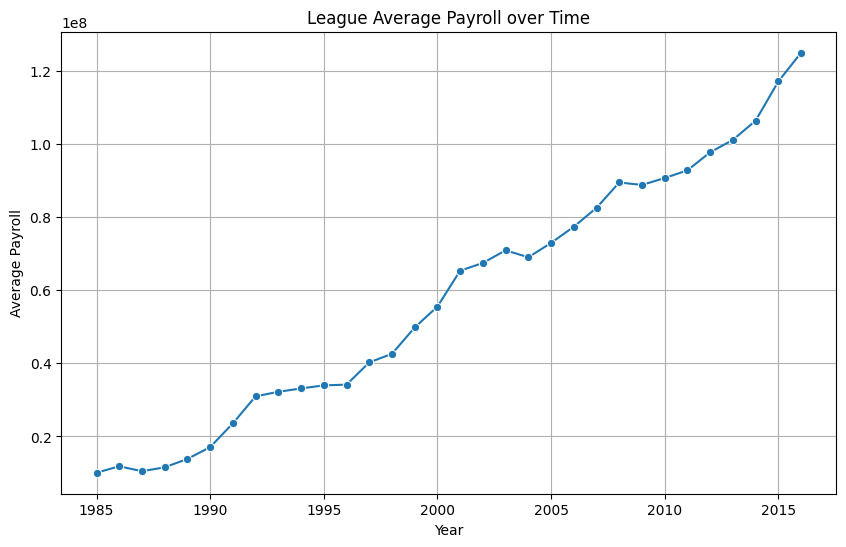

In [14]:
# Payroll by Year Trend (League Average Payroll over Time)
plt.figure(figsize=(10, 6))
average_payroll = df.groupby('yearID')['payroll'].mean().reset_index()
sns.lineplot(
        data = average_payroll,
        x = 'yearID',
        y = 'payroll',
        marker='o'
)
plt.title('League Average Payroll over Time')
plt.xlabel('Year')
plt.ylabel('Average Payroll')
plt.grid(True)
plt.show()

C:\Users\tcbailey\AppData\Local\Temp\ipykernel_11060\547931659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


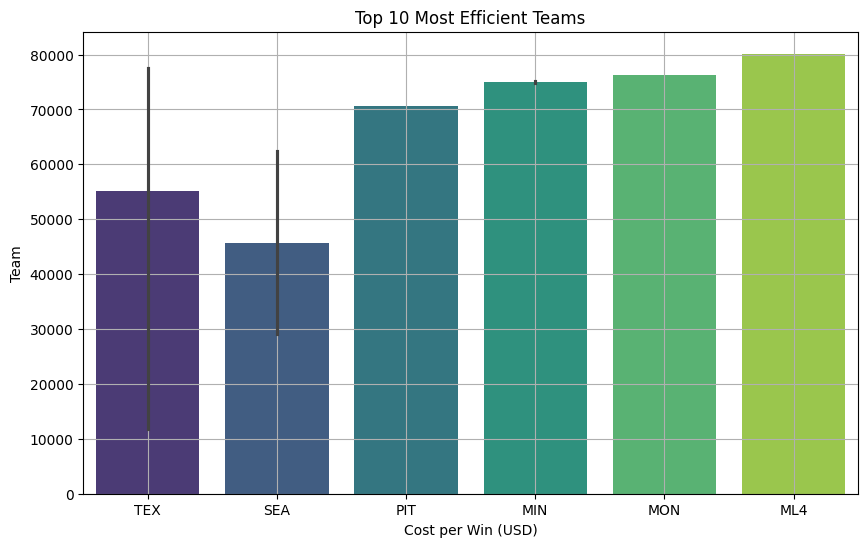

In [15]:
# Top 10 Most Efficient Teams (Lowest Cost per Win)
efficient = df.sort_values('cost_per_win').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
        data = efficient,
        x = 'teamID',
        y = 'cost_per_win',
        palette='viridis'
)

plt.title("Top 10 Most Efficient Teams")
plt.xlabel("Cost per Win (USD)")
plt.ylabel("Team")
plt.grid(True)
plt.show()

C:\Users\tcbailey\AppData\Local\Temp\ipykernel_11060\664212811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


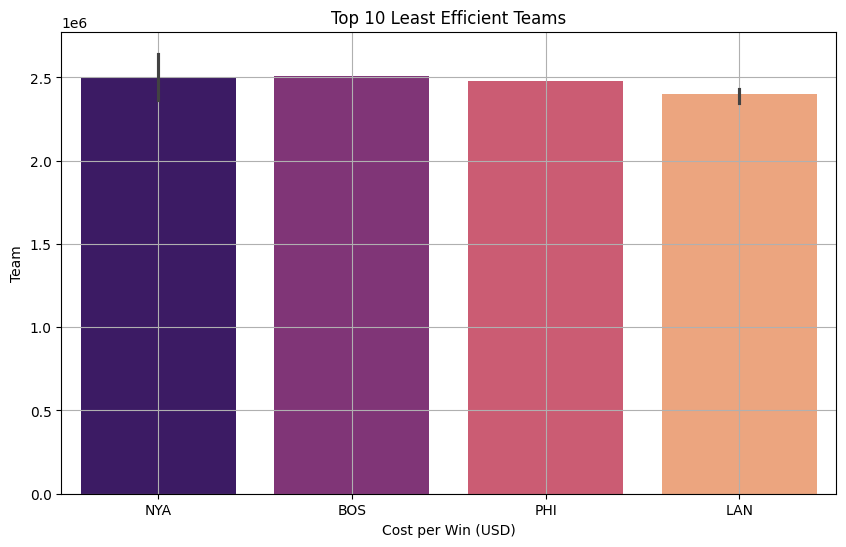

In [16]:
# Most Expensive Teams (Highest Payroll)
inefficient = df.sort_values('cost_per_win', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
        data = inefficient,
        x = 'teamID',
        y = 'cost_per_win',
        palette='magma'
)
plt.title("Top 10 Least Efficient Teams")
plt.xlabel("Cost per Win (USD)")
plt.ylabel("Team")
plt.grid(True)
plt.show()

C:\Users\tcbailey\AppData\Local\Temp\ipykernel_11060\994275761.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


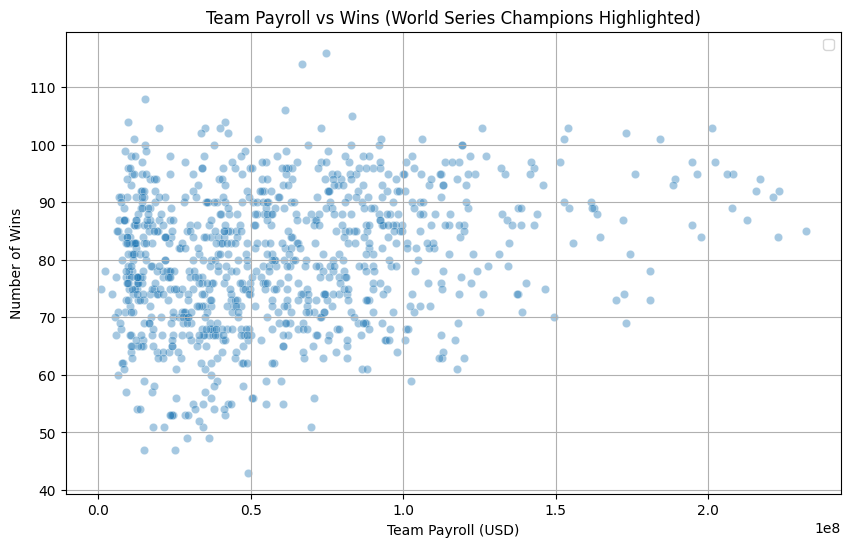

In [17]:
# Teams Winning World Series
champions = df[df['WSWin'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='payroll',
    y='W',
    alpha=0.4
)

sns.scatterplot(
    data=champions,
    x='payroll',
    y='W',
    color='red',
    s=100,
    label='World Series Champions'
)

plt.title('Team Payroll vs Wins (World Series Champions Highlighted)')
plt.xlabel('Team Payroll (USD)')
plt.ylabel('Number of Wins')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Highest Win Totals with Lowest Payroll
underdogs = df.sort_values(['W', 'payroll'], ascending=[False, True]).head(10)
print(underdogs[['yearID', 'teamID', 'payroll', 'W']])

     yearID teamID   payroll    W
462    2001    SEA  74720834  116
366    1998    NYA  66806867  114
42     1986    NYN  15393714  108
350    1998    ATL  61186000  106
554    2004    SLN  83228333  105
95     1988    OAK   9690000  104
208    1993    ATL  41641417  104
147    1990    OAK  19887501  103
232    1993    SFN  35050000  103
488    2002    OAK  40004167  103


In [19]:
# Save Visuals
plt.figure(figsize=(10, 6))
sns.regplot(
        data = df,
        x = 'payroll',
        y = 'W',
        scatter_kws={'alpha': 0.6}
)
plt.title('Team Payroll vs Wins')
plt.xlabel('Team Payroll (USD)')
plt.ylabel('Number of Wins')
plt.grid(True)
plt.savefig('../outputs/payroll_vs_wins.png')
plt.close()

In [20]:
# Summary and Way Ahead
print("Advanced Notebook Section Complete.")
print("Next step = Build Linear Regression Model.")

Advanced Notebook Section Complete.
Next step = Build Linear Regression Model.


In [21]:
# Linear Regression + Machine Learning Model
# Importing machine learning tools
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Machine Learning section ready for implementation.")

Machine Learning section ready for implementation.


In [23]:
# Select features and target variable (Predict wins based on payroll)
X = df[['payroll']]
y = df['W']

In [25]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

Data split into training and testing sets.


In [26]:
# Build Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Predictions
predictions = model.predict(X_test)
print("Predictions made on test set.")

Predictions made on test set.


In [28]:
# Model Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae: .2f}")
print(f"Mean Squared Error: {mse: .2f}")
print(f"Root Mean Squared Error: {rmse: .2f}")
print(f"R-squared: {r2: .3f}")

Mean Absolute Error:  9.17
Mean Squared Error:  126.88
Root Mean Squared Error:  11.26
R-squared:  0.035


In [31]:
# Model Coefficients
print("Intercept:", round(model.intercept_, 2))
print("Payroll Coefficient:", model.coef_[0])

Intercept: 75.71
Payroll Coefficient: 7.120543541000949e-08


In [32]:
# Actual vs Predicted Wins
results = pd.DataFrame(
    {'Actual' : y_test, 'Predicted': predictions}
)
print(results.head(15))

     Actual  Predicted
668      92  82.675090
30       72  76.447387
377      88  79.363761
535      76  79.024770
807      93  86.100756
793      88  83.559531
363      74  78.120436
583     100  82.264018
165      65  76.620678
483      56  79.286277
773      61  81.985619
551      87  79.649212
768      81  80.960816
694      87  80.355173
718      80  79.766336


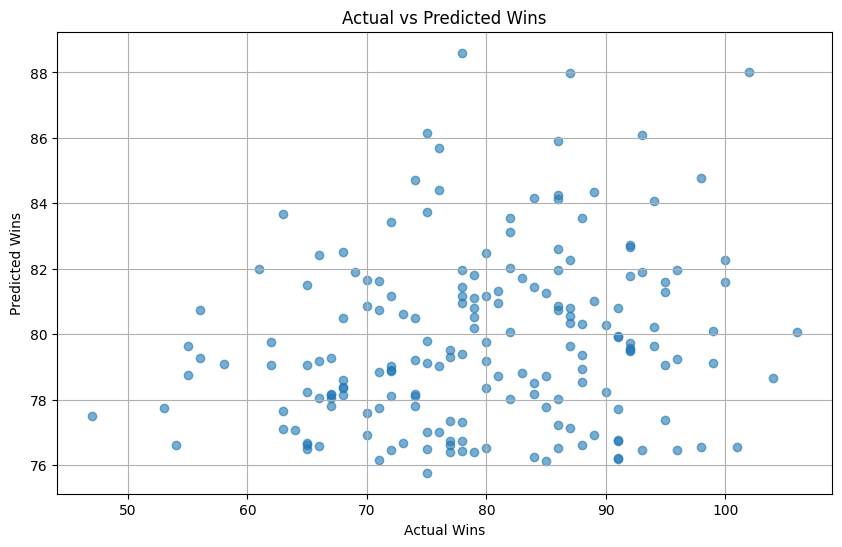

In [39]:
# Visualization
plt.figure(figsize=(10, 6))

plt.scatter(y_test, predictions, alpha=0.6)
plt.title('Actual vs Predicted Wins')
plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.grid(True)
plt.show()
plt.savefig('../outputs/actual_vs_predicted_wins.png')
plt.close()

In [36]:
# Predict Example Team and Add to DataFrame
example_payroll = pd.DataFrame({'payroll': [200000000]})  # Example payroll of $200 million
predicted_wins = model.predict(example_payroll)
print(f"Predicted wins for a team with a $200 million payroll: {predicted_wins[0]:.2f}")

df['predicted_wins'] = model.predict(X)
df['difference'] = df['W'] - df['predicted_wins']
print(df[['yearID', 'teamID', 'W', 'predicted_wins', 'difference']].head())

Predicted wins for a team with a $200 million payroll: 89.95
   yearID teamID   W  predicted_wins  difference
0    1985    ATL  66       76.759849  -10.759849
1    1985    BAL  83       76.528696    6.471304
2    1985    BOS  81       76.481476    4.518524
3    1985    CAL  90       76.732855   13.267145
4    1985    CHA  85       76.406612    8.593388


In [37]:
# Biggest Overperformers and Underperformers
overperformers = df.sort_values('difference', ascending = False).head(10)
underperformers = df.sort_values('difference', ascending = True).head(10)

print("Top 10 Overperforming Teams:", overperformers[['yearID', 'teamID', 'W', 'predicted_wins', 'difference']])
print("Top 10 Underperforming Teams:", underperformers[['yearID', 'teamID', 'W', 'predicted_wins', 'difference']])

Top 10 Overperforming Teams:      yearID teamID    W  predicted_wins  difference
462    2001    SEA  116       81.026040   34.973960
366    1998    NYA  114       80.462522   33.537478
42     1986    NYN  108       76.801627   31.198373
95     1988    OAK  104       76.395491   27.604509
350    1998    ATL  106       80.062286   25.937714
147    1990    OAK  103       77.121609   25.878391
208    1993    ATL  104       78.670606   25.329394
232    1993    SFN  103       78.201261   24.798739
23     1985    SLN  101       76.546951   24.453049
488    2002    OAK  103       78.554025   24.445975
Top 10 Underperforming Teams:      yearID teamID   W  predicted_wins  difference
508    2003    DET  43       79.206539  -36.206539
239    1994    CAL  47       77.496770  -30.496770
258    1994    SDN  47       76.767634  -29.767634
529    2004    ARI  51       80.674279  -29.674279
241    1994    CHN  49       78.289366  -29.289366
259    1994    SEA  49       77.786738  -28.786738
255    1994 

In [38]:
# Save Final Dataset and Final Summary
df.to_csv('../data/team_payroll_wins_predictions.csv', index=False)
print("Machine Learning Model complete.")

Machine Learning Model complete.
